<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\e'
<>:85: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\e'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\e'
<>:85: SyntaxWarning: invalid escape sequence '\l'
<>:94: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_71485/1023289687.py:58: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_range, mean_vals, label='$\mu(x)$', color='k')
/tmp/ipykernel_71485/1023289687.py:59: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(x_range, mean_vals - std_var_vals, linestyle='-', label='$\\mu(x) \pm v(x)$', color=colors[2])
/tmp/ipykernel_71485/1023289687.py:64: SyntaxWarning: inva

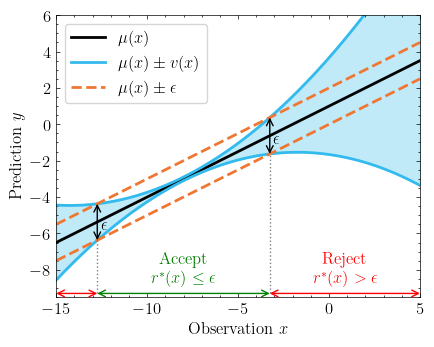

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('halfstyle.mplstyle')

# Get the color cycle from the active style
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
green = 'green'#colors[5]
red = 'red'#colors[4]

xlim = [-15, 5]
# GT model mean
k0 = 1 
k1 = 0.5
# GT model variance
c0 = 0.1
c1 = 0.04
offset = 8
#"""

# Rejection cost epsilon
epsilon = 1.    

# X-axis annotations for Accept/Reject regions
# Position the arrows below the x-axis line
y_lim_bottom = -9.5
y_lim_top = 6
y_arrow_pos = -9.3

def mean_prediction(x):
    """ The optimal predictor h*(x), which is the conditional mean E[y|x]. """
    return k0 + k1 * x

def aleatoric_variance(x):
    """ The conditional risk r*(x), which for L2 loss is the variance Var(y|x). """
    return c0 + c1 * (x + offset)**2

def aleatoric_std_dev(x):
    """ The standard deviation sqrt(Var(y|x)), for visualization purposes. """
    return np.sqrt(aleatoric_variance(x))


# Generate data for plotting
x_range = np.linspace(xlim[0], xlim[1], 500)
mean_vals = mean_prediction(x_range)
std_var_vals = aleatoric_variance(x_range)

epsilon_boundary_on_plot = epsilon

# Determine the accept/reject transition points.
transition_offset = np.sqrt((epsilon - c0) / c1)
x_transition1 = -offset - transition_offset
x_transition2 = -offset + transition_offset

# Create the plot
fig, ax = plt.subplots()

ax.plot(x_range, mean_vals, label='$\mu(x)$', color='k')
ax.plot(x_range, mean_vals - std_var_vals, linestyle='-', label='$\\mu(x) \pm v(x)$', color=colors[2])
ax.plot(x_range, mean_vals + std_var_vals, linestyle='-', color=colors[2])
ax.fill_between(x_range, mean_vals - std_var_vals, mean_vals + std_var_vals,
                color=colors[2], alpha=0.3)

ax.plot(x_range, mean_vals + epsilon_boundary_on_plot, linestyle='--', label='$\\mu(x) \pm \epsilon$', color=colors[0])
ax.plot(x_range, mean_vals - epsilon_boundary_on_plot, linestyle='--', color=colors[0])


for label_x_pos in [x_transition1, x_transition2]:
    mean_at_label_pos = mean_prediction(label_x_pos)
    ax.annotate('', xy=(label_x_pos, mean_at_label_pos - epsilon_boundary_on_plot),
                xytext=(label_x_pos, mean_at_label_pos + epsilon_boundary_on_plot),
                arrowprops=dict(arrowstyle='<->', color='k', shrinkA=0, shrinkB=0))

    ax.text(label_x_pos + 0.2, mean_at_label_pos - 0.2, '$\epsilon$',
            verticalalignment='center', horizontalalignment='left')

    ax.plot([label_x_pos, label_x_pos], [y_arrow_pos, mean_at_label_pos - epsilon_boundary_on_plot],
            color='gray', linestyle='dotted', linewidth=1)

ax.set_ylim(bottom=y_lim_bottom, top=y_lim_top)

# Accept arrow
ax.annotate('', xy=(x_transition1, y_arrow_pos), xytext=(x_transition2, y_arrow_pos),
            arrowprops=dict(arrowstyle='<->', color=green, shrinkA=0, shrinkB=0))
ax.text((x_transition1 + x_transition2) / 2, y_arrow_pos + 0.4, 'Accept\n$r^*(x) \leq \epsilon$',
        ha='center', va='bottom', color=green)

# Reject arrows
ax.annotate('', xy=(x_range.min(), y_arrow_pos), xytext=(x_transition1, y_arrow_pos),
            arrowprops=dict(arrowstyle='<->', color=red, shrinkA=0, shrinkB=0))

ax.annotate('', xy=(x_transition2, y_arrow_pos), xytext=(x_range.max(), y_arrow_pos),
            arrowprops=dict(arrowstyle='<->', color=red, shrinkA=0, shrinkB=0))
ax.text(x_transition2 + (x_range.max()-x_transition2)/2, y_arrow_pos + 0.4, 'Reject\n$r^*(x) > \epsilon$',
        ha='center', va='bottom', color=red)

ax.set_xlabel('Observation $x$')
ax.set_ylabel('Prediction $y$')
ax.legend(loc='upper left')
plt.xlim(xlim)
ax.set_aspect(1)
plt.tight_layout()
plt.savefig("figure_aleatoric.pdf", dpi=400, bbox_inches='tight')
plt.show()